# Generate all figures

*Phase transitions reveal hierarchical structure in deep neural networks*

**Place this notebook inside the `data_availability` folder** (next to the CSV files and the `Hessian_path_finder_T4/` directory) and run the cells top to bottom. Each figure cell displays the plot inline and writes a vector PDF (`Figure_02.pdf` … `Figure_06.pdf`) into the same folder.

Requirements: `matplotlib`, `pandas`, `numpy`.

Run the **Setup** cell first, then any figure cell independently.

## Setup — run first

In [2]:
# Run this cell FIRST. Defines style + imports for every figure below.
# This notebook is meant to live INSIDE the data_availability folder, so the
# data path is the notebook's own directory:
import os, glob
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

DATA = "."          # <-- CSVs and Hessian_path_finder_T4/ sit next to this notebook

# Colourblind-safe palette (Okabe-Ito); blue = error, orange = loss
C_ERROR = "#0072B2"
C_LOSS  = "#E69F00"
C_GREY  = "#4D4D4D"
C_RED   = "#D55E00"
OKABE_ITO = ["#0072B2","#E69F00","#009E73","#CC79A7","#56B4E9",
             "#D55E00","#F0E442","#999999","#000000","#8C564B"]
CMAP_RANK = "plasma"   # perceptually uniform (replaces rainbow)

MM = 1/25.4
DOUBLE_COL = 180*MM

mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02, "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans","Arial","Helvetica"],
    "font.size": 8, "axes.labelsize": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 7.5,
    "axes.linewidth": 0.8, "xtick.major.width": 0.8, "ytick.major.width": 0.8,
    "xtick.major.size": 3, "ytick.major.size": 3,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 1.3, "legend.frameon": False, "axes.grid": False,
})

def panel_label(ax, label, dx=-0.16, dy=1.04, size=11):
    ax.text(dx, dy, label, transform=ax.transAxes, fontsize=size,
            fontweight="bold", va="top", ha="left")

print("Style loaded. DATA =", os.path.abspath(DATA))


Style loaded. DATA = /Users/talha/Desktop/paper_with_andres_review/data_availability


## Figure 2 — MNIST phase transitions

Error $E(\theta)$ and loss $\mathcal{L}_\beta$ vs $\beta$ and vs $r_0$, plus per-digit accuracy. Edit the `T_beta` / `T_r0` lists to move the dashed transition markers.

Figure 2 saved


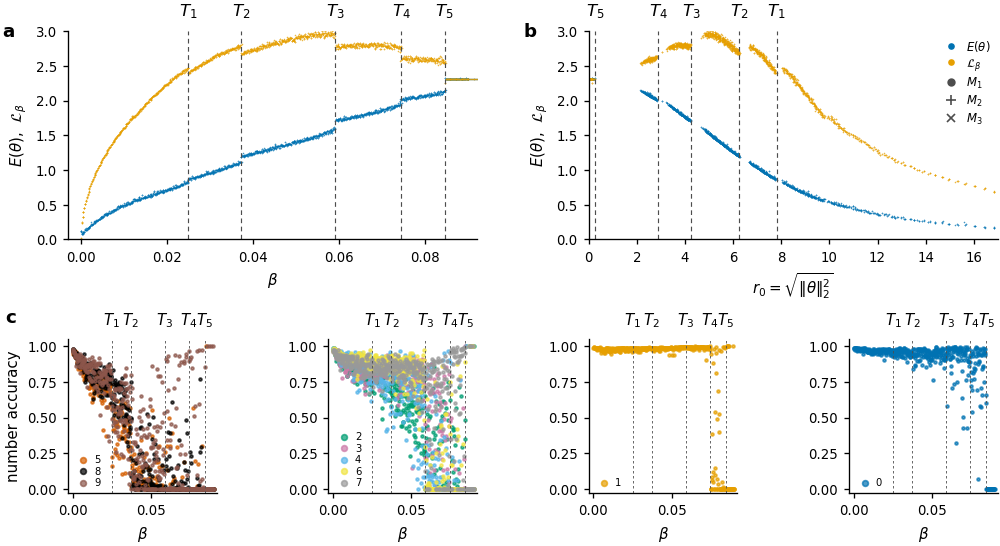

In [107]:
from matplotlib.gridspec import GridSpec

D = DATA + "/"

# ---- load three independently trained models -------------------------------
m1 = pd.read_csv(D+"lr=0.0015_1.csv").sort_values("L2_strength")
m2 = pd.read_csv(D+"lr=0.0015_2.csv").sort_values("L2_strength")
m3 = pd.read_csv(D+"lr=0.0015_3.csv").sort_values("L2_strength")
acc = pd.read_csv(D+"lr=0.0015_1_split_accuracies.csv").sort_values("L2_strength")

# Error E(theta) = test cross-entropy loss ; Loss L_beta = regularized train loss
for d in (m1, m2, m3):
    d["E"] = d["Test_Loss"]
    d["L"] = d["Train_Reg_Loss"]

# Transition beta locations (visually identified hierarchy T1..T5)
T_beta = [0.025, 0.0372, 0.0590, 0.0744, 0.0845]
T_r0   = [7.812, 6.238, 4.255, 2.89, 0.255]   # corresponding r0 markers (approx, descending)
Tlab   = [f"$T_{i}$" for i in range(1, 6)]

# ========== ADJUST THESE PARAMETERS TO MATCH YOUR OTHER FIGURE ==========
# Figure dimensions (width, height) in inches
FIGURE_WIDTH = 10   # Adjust to match your other figure
FIGURE_HEIGHT = 5.0   # Adjust to match your other figure

# GridSpec parameters
N_ROWS = 2
N_COLS = 4
HEIGHT_RATIOS = [1.15, 0.85]  # Adjust as needed
WIDTH_RATIOS = [1, 1, 1, 1]   # Adjust as needed
HSPACE = 0.55  # Horizontal space between subplots
WSPACE = 0.75  # Vertical space between subplots

# Font sizes to match other figure
TITLE_FONTSIZE = 10
LABEL_FONTSIZE = 9
LEGEND_FONTSIZE = 7
TICK_FONTSIZE = 8
# ========================================================================

fig = plt.figure(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
gs = GridSpec(N_ROWS, N_COLS, figure=fig, 
              height_ratios=HEIGHT_RATIOS,
              width_ratios=WIDTH_RATIOS,
              hspace=HSPACE, wspace=WSPACE)

axA = fig.add_subplot(gs[0, 0:2])
axB = fig.add_subplot(gs[0, 2:4])
# four narrow accuracy panels on the bottom row
axC = [fig.add_subplot(gs[1, j]) for j in range(4)]

# ---------- (a) vs beta -------------------------------------------------------
for d, mk in ((m1, "."), (m2, "+"), (m3, "x")):
    axA.scatter(d.L2_strength, d.E, s=0.5, c=C_ERROR, marker=mk, alpha=0.75, linewidths=0.6)
    axA.scatter(d.L2_strength, d.L, s=0.5, c=C_LOSS,  marker=mk, alpha=0.75, linewidths=0.6)
for tb, tl in zip(T_beta, Tlab):
    axA.axvline(tb, color=C_GREY, lw=0.7, ls=(0, (4, 3)))
    axA.text(tb, 3.15, tl, ha="center", va="bottom", fontsize=TITLE_FONTSIZE)
axA.set_xlabel(r"$\beta$", fontsize=LABEL_FONTSIZE)
axA.set_ylabel(r"$E(\theta)$,  $\mathcal{L}_\beta$", fontsize=LABEL_FONTSIZE)
axA.set_xlim(-0.003, 0.092)
axA.set_ylim(0, 3.0)
axA.tick_params(labelsize=TICK_FONTSIZE)
panel_label(axA, "a")

# ---------- (b) vs r0 ---------------------------------------------------------
for d, mk in ((m1, "."), (m2, "+"), (m3, "x")):
    axB.scatter(d.r0, d.E, s=0.5, c=C_ERROR, marker=mk, alpha=0.75, linewidths=0.6)
    axB.scatter(d.r0, d.L, s=0.5, c=C_LOSS,  marker=mk, alpha=0.75, linewidths=0.6)
for tr, tl in zip(T_r0, Tlab):
    axB.axvline(tr, color=C_GREY, lw=0.7, ls=(0, (4, 3)))
    axB.text(tr, 3.15, tl, ha="center", va="bottom", fontsize=TITLE_FONTSIZE)
axB.set_xlabel(r"$r_0=\sqrt{\|\theta\|_2^2}$", fontsize=LABEL_FONTSIZE)
axB.set_ylabel(r"$E(\theta)$,  $\mathcal{L}_\beta$", fontsize=LABEL_FONTSIZE)
axB.set_xlim(0, 17)
axB.set_ylim(0, 3.0)
axB.tick_params(labelsize=TICK_FONTSIZE)
panel_label(axB, "b")

# shared legend for a/b (markers + colours)
leg = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_ERROR, markersize=5, label=r'$E(\theta)$'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_LOSS,  markersize=5, label=r'$\mathcal{L}_\beta$'),
    Line2D([0],[0], marker='.', color=C_GREY, lw=0, markersize=8, label=r'$M_1$'),
    Line2D([0],[0], marker='+', color=C_GREY, lw=0, markersize=6, label=r'$M_2$'),
    Line2D([0],[0], marker='x', color=C_GREY, lw=0, markersize=5, label=r'$M_3$'),
]
axB.legend(handles=leg, loc="upper right", ncol=1, fontsize=LEGEND_FONTSIZE, 
           handletextpad=0.3, labelspacing=0.25, borderaxespad=0.2)

# ---------- (c) per-digit accuracy, grouped by transition behaviour ----------
classcols = [f"Class_{i}_Accuracy" for i in range(10)]
beta = acc.L2_strength.values
# grouping consistent with paper: multi-loss group, mixed group, digit1, digit0
groups = [
    ([5, 8, 9], "digits 5, 8, 9"),
    ([2, 3, 4, 6, 7], "digits 2,3,4,6,7"),
    ([1], "digit 1"),
    ([0], "digit 0"),
]
for ax, (digs, title) in zip(axC, groups):
    for k, dgt in enumerate(digs):
        col = OKABE_ITO[dgt]
        ax.scatter(beta, acc[f"Class_{dgt}_Accuracy"]/100.0,
                   s=3, c=col, alpha=0.7, label=str(dgt))
    for tb in T_beta:
        ax.axvline(tb, color=C_GREY, lw=0.5, ls=(0, (3, 3)))
    ax.set_ylim(-0.03, 1.05)
    ax.set_xlim(-0.003, 0.092)
    ax.set_xticks([0.0, 0.05])
    ax.set_xlabel(r"$\beta$", fontsize=LABEL_FONTSIZE)
    ax.tick_params(labelsize=TICK_FONTSIZE)
    ax.legend(loc="lower left", fontsize=LEGEND_FONTSIZE-1, ncol=1, 
              handletextpad=0.1, labelspacing=0.15, markerscale=2, borderaxespad=0.15)
axC[0].set_ylabel("number accuracy", fontsize=LABEL_FONTSIZE)
axC[0].tick_params(labelsize=TICK_FONTSIZE)
panel_label(axC[0], "c", dx=-0.42, dy=1.2)

# ========== FIX: place T labels above ALL accuracy panels ==========
for ax in axC:  # This adds T_i labels to all four subplots
    for tb, tl in zip(T_beta, Tlab):
        if tb <= 0.092:
            ax.text(tb, 1.12, tl, ha="center", va="bottom", fontsize=TITLE_FONTSIZE-1)

# Save with consistent DPI and bbox_inches='tight' to match other figures
fig.savefig("Figure_02.pdf", dpi=300, bbox_inches='tight')
print("Figure 2 saved")
plt.show()

## Figure 3 — Hessian eigenvalue spectrum

50 largest Hessian eigenvalues vs $r_4$ (coloured by rank, plasma colormap) and the 50th-largest eigenvalue alone.

Figure 3 saved; n_beta = 1118


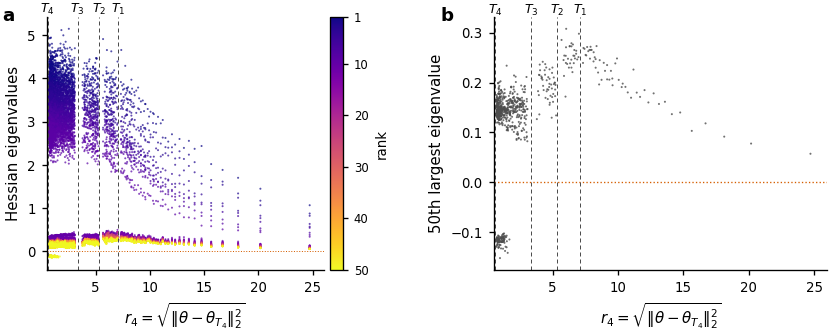

In [8]:
D = DATA + "/"

# map beta -> r4 from the pathfinder trajectory
traj = pd.read_csv(D+"lr=0.0015_path_finder_T4.csv").sort_values("L2_strength")
beta_to_r4 = dict(zip(np.round(traj.L2_strength.values, 6), traj.r4.values))

# load all eigenvalue files (50 eigenvalues each), keyed by beta
files = glob.glob(D+"Hessian_path_finder_T4/*.csv")
def parse_beta(f):
    b = os.path.basename(f).replace("Hessian-eigenvalues-", "").replace(".csv", "")
    return float(b.split("-")[1])

rows = []
for f in files:
    b = parse_beta(f)
    br = round(b, 6)
    if br not in beta_to_r4:
        # nearest match
        keys = np.array(list(beta_to_r4))
        br = keys[np.argmin(np.abs(keys-b))]
    r4 = beta_to_r4[br]
    ev = pd.read_csv(f, header=None)[0].values
    ev_sorted = np.sort(ev)[::-1]   # descending: rank1 largest
    rows.append((r4, ev_sorted))

rows.sort(key=lambda x: x[0])
r4s = np.array([r for r, _ in rows])
EV  = np.vstack([e for _, e in rows])   # shape (n_beta, 50)
n_rank = EV.shape[1]

# transition r4 markers (within the focus window)
#T_r4 = {"$T_4$": 5.4, "$T_3$": 6.8, "$T_2$": 6.238, "$T_1$": 7.812}
T_r4   = {"$T_4$": 0.6, "$T_3$": 3.35, "$T_2$": 5.32, "$T_1$": 7.1, }

XMAX = 26


#T_r0   = [7.812, 6.238, 4.255, 2.89, 0.255]   # corresponding r0 markers (approx, descending)


fig, (axA, axB) = plt.subplots(1, 2, figsize=(DOUBLE_COL, DOUBLE_COL*0.42))

# ---------- (a) all 50 eigenvalues, coloured by rank (plasma, not rainbow) ---
norm = Normalize(vmin=1, vmax=n_rank)
cmap = plt.get_cmap(CMAP_RANK)
for rank in range(n_rank):
    axA.scatter(r4s, EV[:, rank], s=1.5, color=cmap(norm(rank+1)), alpha=0.7,
                edgecolors="none")
axA.axhline(0, color=C_RED, lw=0.6, ls=":")
axA.set_xlim(0.5, XMAX)
ytop = axA.get_ylim()[1]
for tl, tr in T_r4.items():
    axA.axvline(tr, color=C_GREY, lw=0.6, ls=(0, (4, 3)))
    axA.text(tr, ytop, tl, ha="center", va="bottom", fontsize=7.5)
axA.set_xlabel(r"$r_4=\sqrt{\|\theta-\theta_{T_4}\|_2^2}$")
axA.set_ylabel("Hessian eigenvalues")
panel_label(axA, "a")

cb = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=axA, pad=0.02,
                  ticks=[1, 10, 20, 30, 40, 50])
cb.set_label("rank", fontsize=8)
cb.ax.invert_yaxis()
cb.ax.tick_params(labelsize=7)

# ---------- (b) 50th-largest (smallest) eigenvalue alone -------------------
ev50 = EV[:, -1]
axB.scatter(r4s, ev50, s=1.5, color=C_GREY, alpha=0.8, edgecolors="none")
axB.axhline(0, color=C_RED, lw=0.8, ls=":")
axB.set_xlim(0.5, XMAX)
ytopB = axB.get_ylim()[1]
for tl, tr in T_r4.items():
    axB.axvline(tr, color=C_GREY, lw=0.6, ls=(0, (4, 3)))
    axB.text(tr, ytopB, tl, ha="center", va="bottom", fontsize=7.5)
axB.set_xlabel(r"$r_4=\sqrt{\|\theta-\theta_{T_4}\|_2^2}$")
axB.set_ylabel("50th largest eigenvalue")
panel_label(axB, "b")

fig.tight_layout(w_pad=2.5)
fig.savefig("Figure_03.pdf")
print("Figure 3 saved; n_beta =", len(r4s))
plt.show()

## Figure 4 — Mode connectivity

Distance to the reference minimum and the near-zero training error along each connecting path.

Figure 4 saved


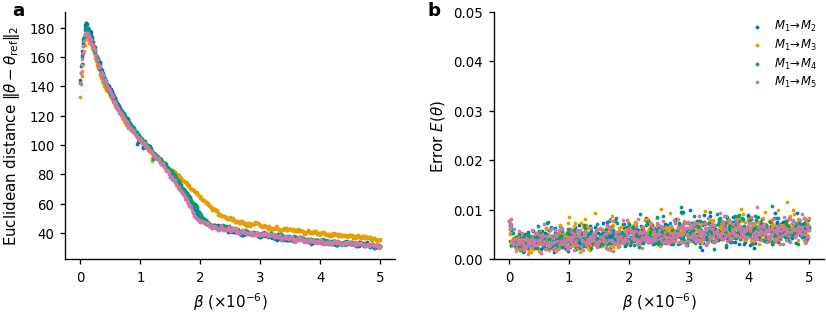

In [127]:
D = DATA + "/"

pairs = [("connect_0_to_1.csv", r"$M_1\!\rightarrow\!M_2$"),
         ("connect_0_to_2.csv", r"$M_1\!\rightarrow\!M_3$"),
         ("connect_0_to_3.csv", r"$M_1\!\rightarrow\!M_4$"),
         ("connect_0_to_4.csv", r"$M_1\!\rightarrow\!M_5$")]
cols = OKABE_ITO[:4]

fig, (axA, axB) = plt.subplots(1, 2, figsize=(DOUBLE_COL, DOUBLE_COL*0.40))

for (f, lab), c in zip(pairs, cols):
    d = pd.read_csv(D+f).sort_values("L2_strength")
    dist_col = [c for c in d.columns if c.startswith("r0-r")][0]
    b = d.L2_strength.values * 1e6           # display in units of 1e-6
    dot_size = 1.5   # systemically chosen, try 10, 15, 20, 30
    axA.scatter(b, d[dist_col], color=c, s=dot_size, lw=1.0, label=lab)
    axB.scatter(b, d["Train_Loss"], color=c, s=dot_size, lw=1.0, label=lab)

axA.set_xlabel(r"$\beta\ (\times 10^{-6})$")
axA.set_ylabel(r"Euclidean distance $\|\theta-\theta_{\mathrm{ref}}\|_2$")
panel_label(axA, "a")  # Keep "a" at original position

axB.set_xlabel(r"$\beta\ (\times 10^{-6})$")
axB.set_ylabel(r"Error $E(\theta)$")
axB.set_ylim(0, 0.05)
axB.legend(loc="upper right", fontsize=7, handlelength=1.4,
           labelspacing=0.3, borderaxespad=0.2)
panel_label(axB, "b", dx=-0.20)  # More negative = further left

fig.tight_layout(w_pad=2.5)
fig.savefig("Figure_04.pdf")
print("Figure 4 saved")
plt.show()

## Figure 5 — Robustness

Same hierarchy at a faster learning rate (0.015) and with a shifted reference point (T4).

Figure 5 saved


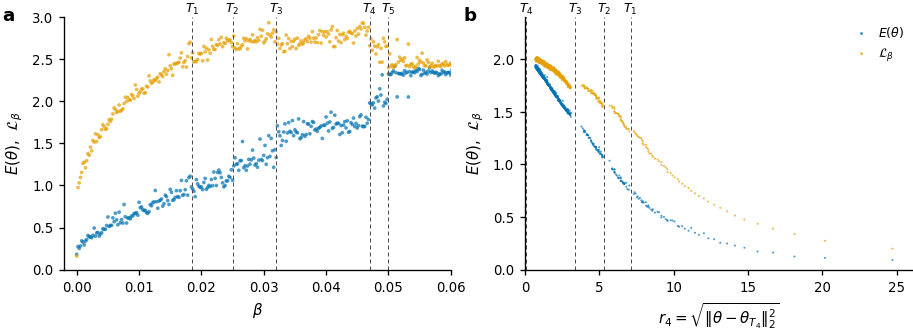

In [125]:
D = DATA + "/"

# (a) faster learning rate 0.015 vs beta ; (b) different ref point (T4) vs r4
lr = pd.read_csv(D+"lr=0.015_1.csv").sort_values("L2_strength")
lr["E"] = lr["Test_Loss"]; lr["L"] = lr["Train_Reg_Loss"]
t4 = pd.read_csv(D+"lr=0.0015_path_finder_T4.csv").sort_values("L2_strength")
t4["E"] = t4["Test_Loss"]; t4["L"] = t4["Train_Reg_Loss"]

T_beta = [0.0185, 0.025, 0.032, 0.047, 0.050]

Tlab   = [f"$T_{i}$" for i in range(1, 6)]
T_r4   = {"$T_4$":0.1 ,"$T_3$": 3.35, "$T_2$": 5.32, "$T_1$": 7.1}


fig, (axA, axB) = plt.subplots(1, 2, figsize=(DOUBLE_COL*1.1, DOUBLE_COL*0.42))

# (a)
axA.scatter(lr.L2_strength, lr.E, s=5, c=C_ERROR, alpha=0.7, edgecolors="none")
axA.scatter(lr.L2_strength, lr.L, s=5, c=C_LOSS,  alpha=0.7, edgecolors="none")
axA.set_xlim(-0.002, 0.06); axA.set_ylim(0, 3.0)
ytop = axA.get_ylim()[1]
for tb, tl in zip(T_beta, Tlab):
    axA.axvline(tb, color=C_GREY, lw=0.6, ls=(0, (4, 3)))
    axA.text(tb, ytop, tl, ha="center", va="bottom", fontsize=7.5)
axA.set_xlabel(r"$\beta$")
axA.set_ylabel(r"$E(\theta)$,  $\mathcal{L}_\beta$")
panel_label(axA, "a")

# (b) reference at T4, plotted vs r4
axB.scatter(t4.r4, t4.E, s=1.5, c=C_ERROR, alpha=0.7, edgecolors="none", label=r"$E(\theta)$")
axB.scatter(t4.r4, t4.L, s=1.5, c=C_LOSS,  alpha=0.7, edgecolors="none", label=r"$\mathcal{L}_\beta$")
axB.set_xlim(0, 26); axB.set_ylim(0, 2.4)
ytopB = axB.get_ylim()[1]
for tl, tr in T_r4.items():
    axB.axvline(tr, color=C_GREY, lw=0.6, ls=(0, (4, 3)))
    axB.text(tr, ytopB, tl, ha="center", va="bottom", fontsize=7.5)
axB.set_xlabel(r"$r_4=\sqrt{\|\theta-\theta_{T_4}\|_2^2}$")
axB.set_ylabel(r"$E(\theta)$,  $\mathcal{L}_\beta$")
axB.legend(loc="upper right", fontsize=7.5, handletextpad=0.3, borderaxespad=0.2, markerscale=1.5)
panel_label(axB, "b")

fig.tight_layout(w_pad=0)
fig.savefig("Figure_05.pdf")
print("Figure 5 saved")
plt.show()

## Figure 6 — Generalization

Transition curves for Fashion-MNIST (sigmoid), Fashion-MNIST (ReLU), and a CNN on synthetic patterns. Transitions auto-detected.

Figure 6 saved


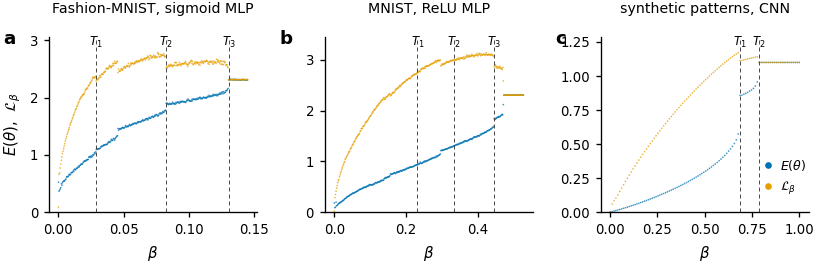

Figure 6 saved
Figure 7 saved (r0 vs β)


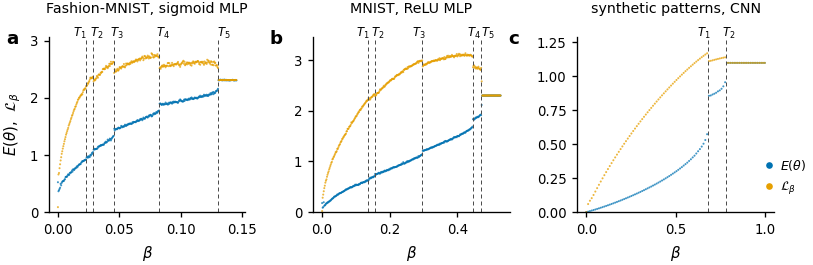

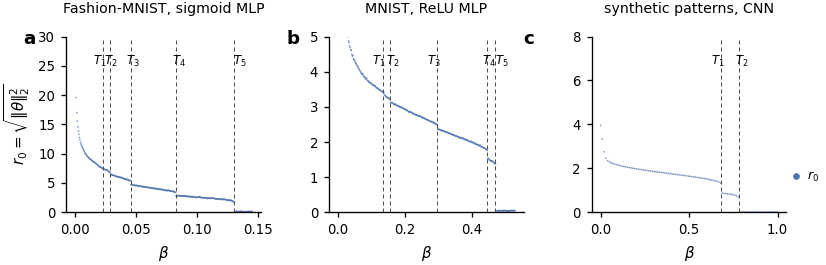

In [97]:
D = DATA + "/"

# ========== MANUAL TRANSITION POINTS (beta values) ==========
# Fashion-MNIST (5 transitions)
MANUAL_TRANSITIONS_FASHION = [0.023, 0.02855, 0.0456, 0.0825, 0.13]

# MNIST ReLU (5 transitions)
MANUAL_TRANSITIONS_MNIST = [0.136, 0.157, 0.296, 0.445, 0.47]

# Synthetic CNN (3 transitions)
MANUAL_TRANSITIONS_CNN = [0.68, 0.78]

# ========== CREATE MAPPING FROM TITLE TO TRANSITIONS ==========
MANUAL_TRANSITIONS = {
    "Fashion-MNIST, sigmoid MLP": MANUAL_TRANSITIONS_FASHION,
    "MNIST, ReLU MLP": MANUAL_TRANSITIONS_MNIST,
    "synthetic patterns, CNN": MANUAL_TRANSITIONS_CNN
}

# ========== Y-LIMITS FOR FIGURE 7 ==========
# Set custom y-limits for each dataset in Figure 7
Y_LIMITS_FIG7 = {
    'fashion': (0, 30),    # (ymin, ymax) for Fashion-MNIST
    'mnist': (0, 5),      # (ymin, ymax) for MNIST
    'cnn': (0, 8)          # (ymin, ymax) for CNN
}

# ========== PANELS ==========
panels = [
    ("lr=0.0015_with_Fashion_MNST.csv",
     "Fashion-MNIST, sigmoid MLP", 5, 'fashion'),  # 5 transitions
    ("lr=0.0015_with_ReLU.csv",
     "MNIST, ReLU MLP", 5, 'mnist'),              # 5 transitions
    ("lr=0.01_with_CNNs_artifical_data.csv",
     "synthetic patterns, CNN", 3, 'cnn'),        # 3 transitions
]

# ========== FIGURE 6: Loss/Error vs β (Original) ==========
fig6, axes6 = plt.subplots(1, 3, figsize=(DOUBLE_COL, DOUBLE_COL*0.34))

for idx, (ax, (f, title, ntr, _), lab) in enumerate(zip(axes6, panels, ["a", "b", "c"])):
    d = pd.read_csv(D+f).sort_values("L2_strength")
    d["E"] = d["Test_Loss"]
    d["L"] = d["Train_Reg_Loss"]
    ax.scatter(d.L2_strength, d.E, s=1.5, c=C_ERROR, alpha=0.75, edgecolors="none")
    ax.scatter(d.L2_strength, d.L, s=1.5, c=C_LOSS,  alpha=0.75, edgecolors="none")
    
    # Use manual transitions
    Tb = MANUAL_TRANSITIONS[title]
    
    ytop = max(d.L.max(), d.E.max()) * 1.3
    ax.set_ylim(0, ytop*0.85)
    
    # Collective y-position for all labels
    y_label_pos = ytop * 0.83
    
    for k, tb in enumerate(Tb, 1):
        ax.axvline(tb, color=C_GREY, lw=0.6, ls=(0, (4, 3)))
        
        # Start with original x position
        x_pos = tb
        
        # Individual x-direction shifts to prevent overlap
        if title == "Fashion-MNIST, sigmoid MLP":
            if k == 1:  # T1
                x_pos = tb - 0.005
            elif k == 2:  # T2
                x_pos = tb + 0.003
            elif k == 3:  # T3
                x_pos = tb + 0.002
            elif k == 4:  # T4
                x_pos = tb + 0.003
            elif k == 5:  # T5
                x_pos = tb + 0.005
                
        elif title == "MNIST, ReLU MLP":
            if k == 1:  # T1
                x_pos = tb - 0.015
            elif k == 2:  # T2
                x_pos = tb + 0.008
            elif k == 3:  # T3
                x_pos = tb - 0.01
            elif k == 4:  # T4
                x_pos = tb + 0.005
            elif k == 5:  # T5
                x_pos = tb + 0.02
                
        elif title == "synthetic patterns, CNN":
            if k == 1:  # T1
                x_pos = tb - 0.02
            elif k == 2:  # T2
                x_pos = tb + 0.015
            elif k == 3:  # T3 (if exists)
                x_pos = tb + 0.01
        
        # Place label with collective y-shift and individual x-shift
        ax.text(x_pos, y_label_pos, f"$T_{k}$", ha="center", va="bottom", fontsize=7)
    
    ax.set_xlabel(r"$\beta$")
    ax.set_title(title, fontsize=8.5, pad=14)
    
    # Adjust dx for panel label
    if lab == "c":
        panel_label(ax, lab, dx=-0.35)
    else:
        panel_label(ax, lab, dx=-0.22)

axes6[0].set_ylabel(r"$E(\theta)$,  $\mathcal{L}_\beta$")

leg = [Line2D([0],[0], marker='o', color='w', markerfacecolor=C_ERROR, markersize=5, label=r'$E(\theta)$'),
       Line2D([0],[0], marker='o', color='w', markerfacecolor=C_LOSS,  markersize=5, label=r'$\mathcal{L}_\beta$')]
axes6[2].legend(handles=leg, loc="center right", fontsize=7.5, bbox_to_anchor=(1.0, 0.2),
               handletextpad=-0.10, borderaxespad=-3)

fig6.tight_layout(w_pad=0)
fig6.savefig("Figure_06.pdf")
print("Figure 6 saved")

# ========== FIGURE 7: r0 (L2 norm) vs β ==========
fig7, axes7 = plt.subplots(1, 3, figsize=(DOUBLE_COL, DOUBLE_COL*0.34))

for idx, (ax, (f, title, ntr, key), lab) in enumerate(zip(axes7, panels, ["a", "b", "c"])):
    d = pd.read_csv(D+f).sort_values("L2_strength")
    
    # Plot r0 vs β
    ax.scatter(d.L2_strength, d.r0, s=1, c='#4C72B0', alpha=0.75, edgecolors="none", label=r'$r_0$')
    
    # Use manual transitions
    Tb = MANUAL_TRANSITIONS[title]
    
    # Apply custom y-limits
    y_min, y_max = Y_LIMITS_FIG7[key]
    ax.set_ylim(y_min, y_max)
    
    # Collective y-position for T labels (shifted downward)
    y_label_pos = y_max * 0.9
    
    for k, tb in enumerate(Tb, 1):
        ax.axvline(tb, color=C_GREY, lw=0.6, ls=(0, (4, 3)))
        
        # Start with original x position
        x_pos = tb
        
        # Individual x-direction shifts to prevent overlap
        if title == "Fashion-MNIST, sigmoid MLP":
            if k == 1:  # T1
                x_pos = tb - 0.003
            elif k == 2:  # T2
                x_pos = tb + 0.001
            elif k == 3:  # T3
                x_pos = tb + 0.002
            elif k == 4:  # T4
                x_pos = tb + 0.003
            elif k == 5:  # T5
                x_pos = tb + 0.005
                
        elif title == "MNIST, ReLU MLP":
            if k == 1:  # T1
                x_pos = tb - 0.015
            elif k == 2:  # T2
                x_pos = tb + 0.008
            elif k == 3:  # T3
                x_pos = tb - 0.01
            elif k == 4:  # T4
                x_pos = tb + 0.005
            elif k == 5:  # T5
                x_pos = tb + 0.02
                
        elif title == "synthetic patterns, CNN":
            if k == 1:  # T1
                x_pos = tb - 0.02
            elif k == 2:  # T2
                x_pos = tb + 0.015
        
        # Place label with collective y-shift and individual x-shift
        ax.text(x_pos, y_label_pos, f"$T_{k}$", ha="center", va="top", fontsize=7)
    
    ax.set_xlabel(r"$\beta$")
    ax.set_title(title, fontsize=8.5, pad=14)
    
    # Adjust dx for panel label
    if lab == "c":
        panel_label(ax, lab, dx=-0.35)
    else:
        panel_label(ax, lab, dx=-0.22)

axes7[0].set_ylabel(r"$r_0 = \sqrt{\|\theta\|_2^2}$")

# Add legend for Figure 7
leg7 = [Line2D([0],[0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=5, label=r'$r_0$')]
axes7[2].legend(handles=leg7, loc="center right", fontsize=7.5, bbox_to_anchor=(1.0, 0.2),
                handletextpad=-0.10, borderaxespad=-3)

fig7.tight_layout(w_pad=0)
fig7.savefig("Figure_07_r0_vs_beta.pdf")
print("Figure 7 saved (r0 vs β)")
plt.show()

In [ ]:
´